Лабораторная работа по машинному обучению.
Работу выполнила: студентка группы 3825М1ФИ2, Шишкина Валерия Алексеевна

Информация о датасете: 

Глобальная база данных по терроризму (GTD) — это база данных с открытым исходным кодом, содержащая информацию о террористических актах по всему миру с 1970 по 2017 год. GTD содержит систематизированные данные о внутренних и международных террористических актах, произошедших за этот период, и на сегодняшний день содержит информацию о более чем 180 000 атак.

Признаки:
1. Идентификаторы и метаданные:
    eventid — уникальный ID события
    related — ID связанных событий
    dbsource — источник в базе
    scite1, scite2, scite3 — источники информации
2. Временные признаки:
   iyear, imonth, iday — год, месяц, день
   approxdate — приблизительная дата
   extended — атака длилась > 24ч
3. Географические признаки:
   country, country_txt — страна
   region, region_txt — регион
   provstate, city — штат/провинция и город
   latitude, longitude - координаты
   specificity — точность локации
   vicinity — в пригороде/за городом
   location — точный адрес
   kidhijcountry — страна угона/захвата (для hijacking/hostage)
4. Критерии терроризма и достоверность:
    crit1, crit2, crit3 — формальные критерии терроризма
    doubtterr — сомнения, что это терроризм
    alternative, alternative_txt — альтернативная интерпретация
    multiple — часть серии атак
5. Характеристики атаки:
    success — успешна ли атака
    suicide — самоубийственная атака
    attacktype1/2/3, attacktype1/2/3_txt — тип(ы) атаки
    attacktype_combined, attacktype_combined_txt — комбинированный тип
6. Цели:
    targtype1/2/3, targtype1/2/3_txt — тип цели
    targsubtype1/2/3, targsubtype1/2/3_txt — подтип цели
    corp1/2/3 — организация-цель
    target1/2/3 — конкретная цель
    natlty1/2/3, natlty1/2/3_txt — национальность цели
7. Исполнители:
    gname, gname2, gname3 — названия групп
    gsubname, gsubname2, gsubname3 — подгруппы
    individual — одиночка
    nperps — число нападавших
    nperpcap — число пойманных
    guncertain1/2/3 — неуверенность в исполнителе
8. Заявления об ответственности:
    claimed — заявила ли группа
    claimmode, claimmode2, claimmode3 — способ заявления
    claimmode_txt и т.д. — текстовые описания способа
    compclaim — конкурирующие заявления
9. Оружие:
    weaptype1/2/3/4, weaptype1/2/3/4_txt — тип оружия
    weapsubtype1/2/3/4, weapsubtype1/2/3/4_txt — подтип оружия
    weapdetail — детали оружия
10. Жертвы и ущерб:
    nkill, nkillus, nkillter — убитые (всего, США, террористы)
    nwound, nwoundus, nwoundter — раненые
    property — нанесён ли ущерб имуществу
    propextent, propextent_txt — масштаб ущерба
    propvalue — стоимость ущерба
    propcomment — комментарий к ущербу
11. Захват заложников, угоны:
    ishostkid — был ли захват
    nhostkid, nhostkidus — число заложников
    nhours, ndays — длительность захвата
    divert — перенаправление транспорта
    ransom — требовался выкуп
    ransomamt, ransomamtus — сумма выкупа
    ransompaid, ransompaidus — выкуп заплачен
    ransomnote — записка с требованиями
    hostkidoutcome, hostkidoutcome_txt — исход захвата
    nreleased — освобождено заложников
12. Международный аспект:
    INT_LOG — международная логистика
    INT_IDEO — международная идеология
    INT_MISC — прочая международная связь
    INT_ANY — любая международная связь
13. Текстовые и дополнительные поля:
    summary — краткое описание события
    motive — мотив (если известен)
    addnotes — дополнительные заметки
    
Задача: многоклассовая классификация типа террористической атаки.
Разработать модель машинного обучения, способную предсказывать тип террористической атаки (attacktype1) на основе доступных признаков события — таких как географическое местоположение, цель, используемое оружие, год, месяц, принадлежность к группе и других характеристик.

I. Чтение данных

In [3]:
import pandas as pd

df = pd.read_csv('globalterrorismdb_0718dist.csv', encoding='cp1252', low_memory=False)
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


В начале поработаем с выводом данных различными способами.

In [5]:
df

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181686,201712310022,2017,12,31,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Al-Shabaab Militants Attack Army Che...","""Highlights: Somalia Daily Media Highlights 2 ...","""Highlights: Somalia Daily Media Highlights 1 ...",START Primary Collection,0,0,0,0,NaN
181687,201712310029,2017,12,31,NaN,0,NaN,200,Syria,10,...,NaN,"""Putin's 'victory' in Syria has turned into a ...","""Two Russian soldiers killed at Hmeymim base i...","""Two Russian servicemen killed in Syria mortar...",START Primary Collection,-9,-9,1,1,NaN
181688,201712310030,2017,12,31,NaN,0,NaN,160,Philippines,5,...,NaN,"""Maguindanao clashes trap tribe members,"" Phil...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
181689,201712310031,2017,12,31,NaN,0,NaN,92,India,6,...,NaN,"""Trader escapes grenade attack in Imphal,"" Bus...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN


In [6]:
print(df)

             eventid  iyear  imonth  iday approxdate  extended resolution  \
0       197000000001   1970       7     2        NaN         0        NaN   
1       197000000002   1970       0     0        NaN         0        NaN   
2       197001000001   1970       1     0        NaN         0        NaN   
3       197001000002   1970       1     0        NaN         0        NaN   
4       197001000003   1970       1     0        NaN         0        NaN   
...              ...    ...     ...   ...        ...       ...        ...   
181686  201712310022   2017      12    31        NaN         0        NaN   
181687  201712310029   2017      12    31        NaN         0        NaN   
181688  201712310030   2017      12    31        NaN         0        NaN   
181689  201712310031   2017      12    31        NaN         0        NaN   
181690  201712310032   2017      12    31        NaN         0        NaN   

        country         country_txt  region  ... addnotes  \
0            5

In [7]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


Метод df.head() выводит информацию о первых пяти строках таблицы.

In [8]:
df.tail()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
181686,201712310022,2017,12,31,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Al-Shabaab Militants Attack Army Che...","""Highlights: Somalia Daily Media Highlights 2 ...","""Highlights: Somalia Daily Media Highlights 1 ...",START Primary Collection,0,0,0,0,NaN
181687,201712310029,2017,12,31,NaN,0,NaN,200,Syria,10,...,NaN,"""Putin's 'victory' in Syria has turned into a ...","""Two Russian soldiers killed at Hmeymim base i...","""Two Russian servicemen killed in Syria mortar...",START Primary Collection,-9,-9,1,1,NaN
181688,201712310030,2017,12,31,NaN,0,NaN,160,Philippines,5,...,NaN,"""Maguindanao clashes trap tribe members,"" Phil...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
181689,201712310031,2017,12,31,NaN,0,NaN,92,India,6,...,NaN,"""Trader escapes grenade attack in Imphal,"" Bus...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN
181690,201712310032,2017,12,31,NaN,0,NaN,160,Philippines,5,...,NaN,"""Security tightened in Cotabato following IED ...","""Security tightened in Cotabato City,"" Manila ...",NaN,START Primary Collection,-9,-9,0,-9,NaN


Метод df.tail() выводит информацию о последних пяти строках таблицы.

Теперь посмотрим на размеры таблицы:количество строк (каждая строка - отдельное террористическое событие), количечество столбцов (каждый столбец - конкретный признак).

In [9]:
print(df.shape)

(181691, 135)


Видим, что количество событий - 181691, количество признаков - 135.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


<class 'pandas.core.frame.DataFrame'> — это объект типа DataFrame.
RangeIndex: 181691 entries — у тебя 181 691 строк (событий).
Columns: 135 entries — ровно 135 колонок (признаков), как и в GTD.
dtypes: float64(55), int64(22), object(58) — распределение типов данных:
float64 — 55 колонок (например, latitude, longitude, nkill, nwound)
int64 — 22 колонки (например, iyear, country, attacktype1)
object — 58 колонок (текстовые поля: city, summary, gname, country_txt и т.д.)
memory usage: 187.1+ MB — объём памяти, занимаемый датафреймом.

In [11]:
print(df.columns)

Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY', 'related'],
      dtype='object', length=135)


Метод print(df.columns) используется для вывода названий столбцов. В процессе решения задачи, может понадобиться переименовать столбцы таблицы, это можно сделать с помощью метода df.rename(columns=...).

In [12]:
df.index

RangeIndex(start=0, stop=181691, step=1)

В процессе решения задачи может потребоваться обратить к какому-то одному или нескольким отдельным столбцам, к отдельному элементу, получить тип элеменета или признака, и т.д. Это можно сделать следующим образом:

In [13]:
df.at[3, 'attacktype1']

3

In [14]:
df['attacktype1']

0         1
1         6
2         1
3         3
4         7
         ..
181686    2
181687    3
181688    7
181689    3
181690    3
Name: attacktype1, Length: 181691, dtype: int64

In [15]:
df['attacktype1'][2]

1

In [16]:
df['attacktype1'].dtype.name

'int64'

In [17]:
type(df['attacktype1'][3])

numpy.int64

In [18]:
type(df['attacktype1'])

pandas.core.series.Series

In [20]:
df[['success', 'attacktype1']].head()

,success,attacktype1
0,1,1
1,1,6
2,1,1
3,1,3
4,1,7


На основании выведенных данных можно увидеть, что атаки разных типов были успешно реализованы.

In [21]:
df_small = df[['iyear', 'country_txt', 'region_txt', 'attacktype1_txt', 'nkill', 'nwound']]

In [22]:
df_small

,iyear,country_txt,region_txt,attacktype1_txt,nkill,nwound
0,1970,Dominican Republic,Central America & Caribbean,Assassination,1.0,0.0
1,1970,Mexico,North America,Hostage Taking (Kidnapping),0.0,0.0
2,1970,Philippines,Southeast Asia,Assassination,1.0,0.0
3,1970,Greece,Western Europe,Bombing/Explosion,NaN,NaN
4,1970,Japan,East Asia,Facility/Infrastructure Attack,NaN,NaN
...,...,...,...,...,...,...
181686,2017,Somalia,Sub-Saharan Africa,Armed Assault,1.0,2.0
181687,2017,Syria,Middle East & North Africa,Bombing/Explosion,2.0,7.0
181688,2017,Philippines,Southeast Asia,Facility/Infrastructure Attack,0.0,0.0
181689,2017,India,South Asia,Bombing/Explosion,0.0,0.0


Удалем строки, в которых не указан типа атаки.

In [24]:
df_small = df_small.dropna(subset=['attacktype1_txt'])

Посчитаем, сколько раз встречается каждый тип атаки с помощью df_small.dropna().

In [26]:
attack_counts = df_small['attacktype1_txt'].value_counts()
attack_counts

attacktype1_txt
Bombing/Explosion                      88255
Armed Assault                          42669
Assassination                          19312
Hostage Taking (Kidnapping)            11158
Facility/Infrastructure Attack         10356
Unknown                                 7276
Unarmed Assault                         1015
Hostage Taking (Barricade Incident)      991
Hijacking                                659
Name: count, dtype: int64

In [27]:
top5_attacks = attack_counts.head(5)
top5_attacks

attacktype1_txt
Bombing/Explosion                 88255
Armed Assault                     42669
Assassination                     19312
Hostage Taking (Kidnapping)       11158
Facility/Infrastructure Attack    10356
Name: count, dtype: int64

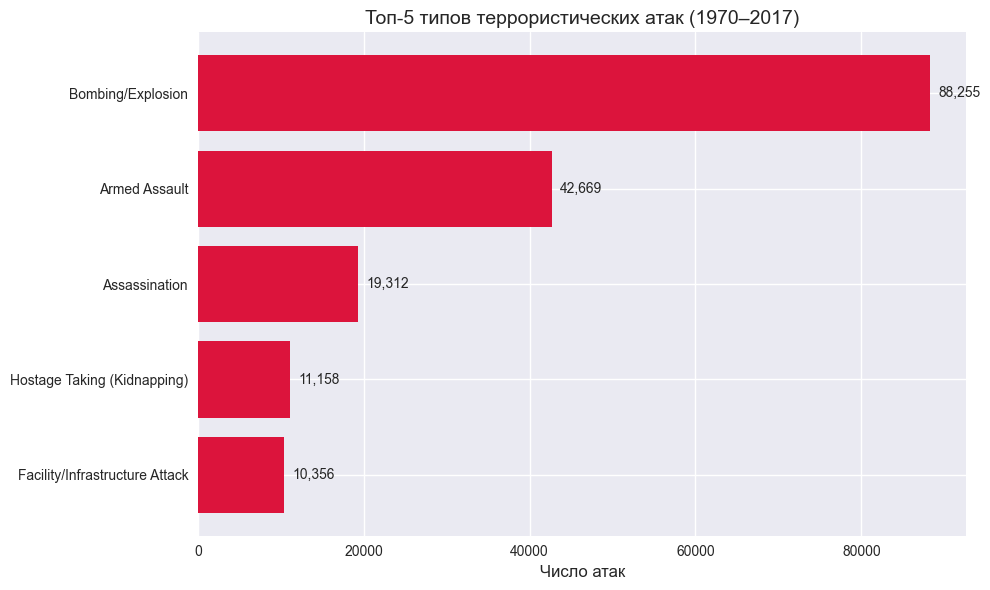

In [29]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top5_attacks.index, top5_attacks.values, color='crimson')
ax.set_xlabel('Число атак', fontsize=12)
ax.set_title('Топ-5 типов террористических атак (1970–2017)', fontsize=14)
ax.invert_yaxis()
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1000, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Наиболее распространённым типом террористической атаки за период 1970–2017 гг. является взрыв/бомбардировка (Bombing/Explosion) — их было 88 255, что почти в 2 раза больше, чем следующий по частоте тип.
Проанализируем динамику терроризма по годам.

In [30]:
attacks_per_year = df['iyear'].value_counts().sort_index()

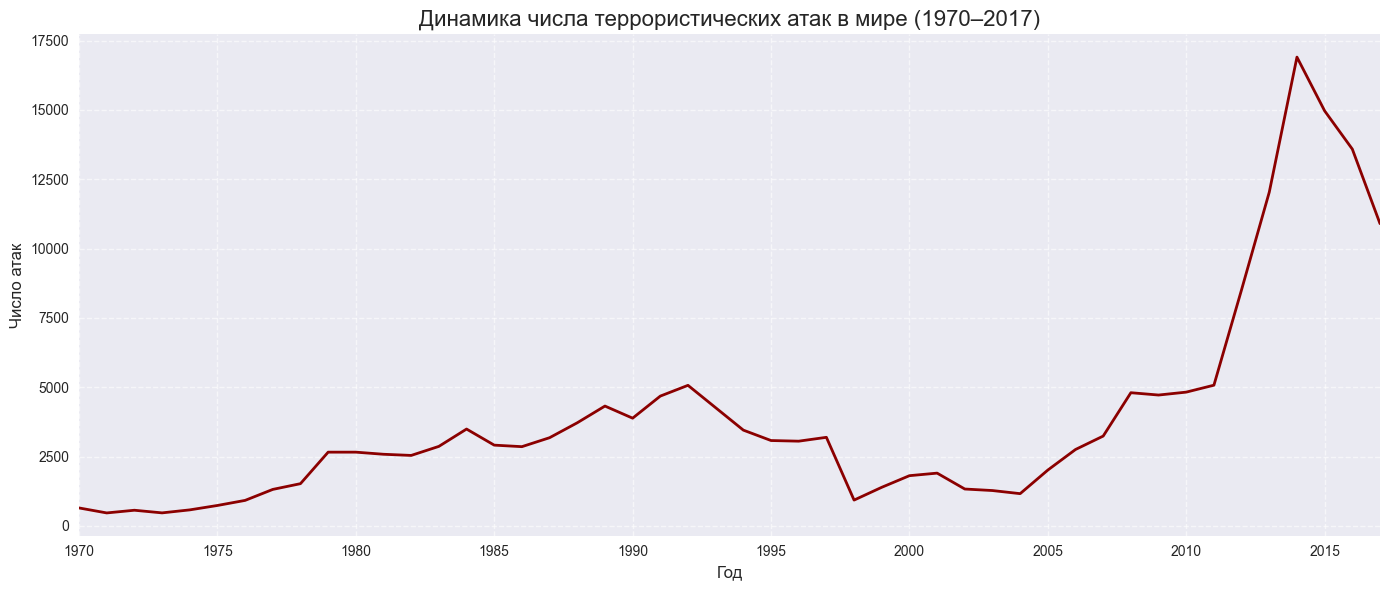

In [42]:
import numpy as np
plt.figure(figsize=(14, 6))
plt.plot(attacks_per_year.index, attacks_per_year.values, color='darkred', linewidth=2)
plt.title('Динамика числа террористических атак в мире (1970–2017)', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Число атак', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(1970, 2017)
plt.xticks(np.arange(1970, 2018, 5))
plt.tight_layout()
plt.show()

Пять самых террористических лет.

In [35]:
top_years = attacks_per_year.nlargest(5)
print("Годы с наибольшим числом атак:")
top_years

Годы с наибольшим числом атак:


iyear
2014    16903
2015    14965
2016    13587
2013    12036
2017    10900
Name: count, dtype: int64

Теперь построим гистрограмму распределения числа жертв.

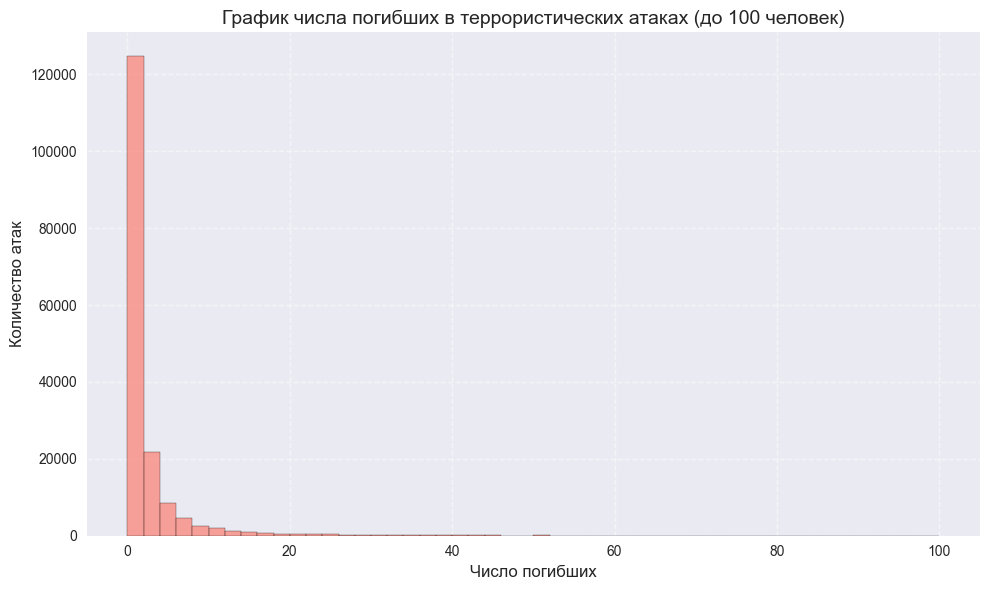

In [46]:
nkill_clean = df['nkill'].dropna()

nkill_limited = nkill_clean[nkill_clean <= 100]

plt.figure(figsize=(10, 6))
plt.hist(nkill_limited, bins=50, color='salmon', edgecolor='black', alpha=0.7)

plt.title('График числа погибших в террористических атаках (до 100 человек)', fontsize=14)
plt.xlabel('Число погибших', fontsize=12)
plt.ylabel('Количество атак', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [48]:
df[['nkill', 'nwound']].describe()

,nkill,nwound
count,171378.000000,165380.000000
mean,2.403272,3.167668
std,11.545741,35.949392
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,2.000000,2.000000
max,1570.000000,8191.000000


Признак nkill (количество погибших в результате атаки):
Данные о числе погибших доступны в 171 378 записях из общего числа 181 690 атак.
Среднее значение составляет 2,4 человека на одну атаку.
Медиана равна 0 - это означает, что в половине всех атак никто не погиб.
Более того, в 75 % атак число погибших не превышает 2 человек.
При этом максимальное значение — 1 570 погибших, что указывает на наличие единичных, но чрезвычайно разрушительных инцидентов.
Высокое стандартное отклонение (11,54) подтверждает сильный разброс данных и наличие редких, но экстремальных значений.

Признак nwound (количество раненых в результате атаки):
Данные о раненых присутствуют в 165 380 записях из общего числа 181 690 атак.
Среднее число раненых — около 3,17 на атаку.
Медиана также равна 0 - это означает, что в половине атак никто не пострадал физически.
75 % атак привели к двум или менее раненым.
Однако максимальное значение — 8 191 раненый, что свидетельствует о наличии масштабных терактов в людных местах.
Стандартное отклонение очень велико - около 35,95, что подтверждает сильный разброс данных.